### Imports & display options: Load pandas/numpy/plotting, set wide display. Bring in StandardScaler, KMeans, silhouette, and TSNE. Define RS and silence warnings.

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.patches import Rectangle

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import sklearn
from sklearn.manifold import TSNE

print("=" * 50)
print(f"Python Version      : {sys.version}")
print(f"Pandas Version      : {pd.__version__}")
print(f"NumPy Version       : {np.__version__}")
print(f"Matplotlib Version  : {matplotlib.__version__}")
print(f"Seaborn Version     : {sns.__version__}")
print(f"Plotly Version      : {plotly.__version__}")
print(f"Scikit-learn Version: {sklearn.__version__}")
print("=" * 50)

# Save to requirements.md
with open(r"Images\K-Means Clusters\requirements.md", "w") as f:
    f.write("# Project Requirements\n\n")
    f.write("## Environment\n\n")
    f.write(f"- Python: {sys.version.split()[0]}\n\n")
    f.write("## Libraries\n\n")
    f.write(f"- pandas=={pd.__version__}\n")
    f.write(f"- numpy=={np.__version__}\n")
    f.write(f"- matplotlib=={matplotlib.__version__}\n")
    f.write(f"- seaborn=={sns.__version__}\n")
    f.write(f"- plotly=={plotly.__version__}\n")
    f.write(f"- scikit-learn=={sklearn.__version__}\n")

print("requirements.md has been created successfully.")

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

# Define a common seed value to be used throughout
RS=0

Python Version      : 3.13.12 | packaged by conda-forge | (main, Feb  5 2026, 05:41:12) [MSC v.1944 64 bit (AMD64)]
Pandas Version      : 2.3.3
NumPy Version       : 2.3.5
Matplotlib Version  : 3.10.6
Seaborn Version     : 0.13.2
Plotly Version      : 6.3.0
Scikit-learn Version: 1.7.2
requirements.md has been created successfully.


In [3]:
# Specify file path
file_path = r"Oils.csv"
# Read the CSV file
data = pd.read_csv(file_path)
df_oils = data.copy()
df_oils = df_oils.drop(columns=['Unnamed: 0'])
df_oils

Oil_Type Oil  500.8563  501.8205  502.7847   503.749  504.7132  505.6774  \
0        SO 0  SO -0.458101 -1.495276 -1.862568 -1.831711 -1.535953 -0.993022   
1        SO 0  SO  0.068097 -0.399315 -0.678853 -0.814568 -0.855950 -0.791816   
2        SO 0  SO  0.167223 -1.133351 -1.652558 -1.617278 -1.226656 -0.573671   
3        SO 0  SO -0.271799 -0.583166 -0.724528 -0.798817 -0.848749 -0.863939   
4        SO 0  SO -0.194513 -0.940731 -1.160886 -1.062074 -0.771085 -0.351588   
..        ...  ..       ...       ...       ...       ...       ...       ...   
995  VO 9      VO -0.034947 -0.180810 -0.391828 -0.642584 -0.917746 -1.148100   
996  VO 9      VO -0.639607 -0.416230 -0.093788  0.188944  0.435340  0.617132   
997  VO 9      VO  0.239122 -0.131614 -0.470480 -0.741282 -0.963708 -1.093654   
998  VO 9      VO  0.441411  0.046997 -0.093115 -0.006286  0.218919  0.493749   
999  VO 9      VO  0.509218  0.538932  0.333033  0.056121 -0.254349 -0.546759   

     506.6417  507.6059  508.5701  509.5344  510.4986  511.4628  512.4271  \
0   -0.391103  0.233167  0.736664  0.991370  0.956672  0.700951  0.449719   
1   -0.674305 -0.513736 -0.342651 -0.190976 -0.068750  0.035006  0.158178   
2    0.003154  0.458940  0.678271  0.660841  0.476559  0.149576 -0.206054   
3   -0.920526 -1.022233 -1.144028 -1.235504 -1.258568 -1.221066 -1.130485   
4   -0.068750  0.085753  0.086389 -0.049578 -0.287679 -0.597473 -0.835858   
..        ...       ...       ...       ...       ...       ...       ...   
995 -1.260009 -1.219511 -1.034384 -0.812137 -0.701306 -0.716923 -0.737459   
996  0.727431  0.707909  0.499717  0.164448 -0.128971 -0.298578 -0.400542   
997 -1.115323 -1.014951 -0.814825 -0.585053 -0.380516 -0.174933  0.109224   
998  0.603295  0.558233  0.378946  0.127683 -0.135317 -0.394342 -0.581880   
999 -0.669432 -0.642831 -0.518620 -0.336601 -0.115073  0.132493  0.320762   

     513.3913  514.3555  515.3198   516.284  517.2482  518.2125  519.1767  \
0    0.244738  0.068509 -0.056937 -0.095208 -0.054344  0.033550  0.174181   
1    0.257007  0.293209  0.267117  0.205402  0.124151  0.025600 -0.086357   
2   -0.458698 -0.556581 -0.595982 -0.690896 -0.847410 -0.968523 -0.958749   
3   -0.978780 -0.783513 -0.585774 -0.433292 -0.321451 -0.220201 -0.116622   
4   -0.928414 -0.923756 -0.844943 -0.687609 -0.441944 -0.168795  0.007971   
..        ...       ...       ...       ...       ...       ...       ...   
995 -0.808927 -0.985596 -1.179307 -1.289544 -1.287319 -1.231989 -1.200206   
996 -0.436871 -0.377856 -0.263907 -0.175587 -0.178344 -0.273663 -0.380336   
997  0.353533  0.460641  0.436405  0.332651  0.177417 -0.016361 -0.203921   
998 -0.623249 -0.547883 -0.420067 -0.285472 -0.139599  0.008037  0.097770   
999  0.345377  0.206514 -0.006959 -0.213094 -0.400342 -0.586358 -0.764731   

     520.1409  521.1052  522.0694  523.0336  523.9979  524.9621  525.9263  \
0    0.395118  0.683926  0.992200  1.180071  1.182973  1.020644  0.753777   
1   -0.177832 -0.173041 -0.049842  0.113304  0.246327  0.328197  0.370578   
2   -0.801991 -0.545173 -0.208500  0.195862  0.591162  0.832790  0.819308   
3   -0.032726 -0.050288 -0.198163 -0.454155 -0.789566 -1.171456 -1.498739   
4    0.023840 -0.065639 -0.214114 -0.368551 -0.475957 -0.435494 -0.292340   
..        ...       ...       ...       ...       ...       ...       ...   
995 -1.200782 -1.217742 -1.285179 -1.427141 -1.593423 -1.632586 -1.473163   
996 -0.431772 -0.491162 -0.607294 -0.734749 -0.815847 -0.870245 -0.883747   
997 -0.313380 -0.358470 -0.412703 -0.569988 -0.809364 -1.042693 -1.204265   
998  0.071974 -0.108498 -0.442006 -0.806642 -1.077495 -1.157047 -1.080248   
999 -0.895696 -0.920941 -0.844384 -0.729825 -0.620531 -0.510037 -0.418282   

     526.8906  527.8548   528.819  529.7833  530.7475  531.7117   532.676  \
0    0.460243  0.180036 -0.069201 -0.278928 -0.437419 -0.525460 -0.566531   
1    0.384977  0.338642  0.190685 -0.041291 -0.257086 -0.376210 -0.392517   
2    0.565549  0.199350 -0

In [4]:
# Spectral data starts from column 2
spectra = df_oils.iloc[:, 2:]

# Most negative value in the entire spectral dataset
min_value = spectra.min().min()

# Find row and column containing the minimum value
row_idx, col_idx = (spectra == min_value).stack().idxmax()

print("Most negative value:", min_value)
print("Most negative value:", min_value)
print("Row index:", row_idx)
print("Wavenumber:", col_idx)

Most negative value: -7.583057172006416
Most negative value: -7.583057172006416
Row index: 622
Wavenumber: 1337.811


In [5]:
# shift = abs(min_value)

# df_oils = df_oils.copy()
# df_oils.iloc[:, 2:] = df_oils.iloc[:, 2:] + shift

# print("New minimum:", df_oils.iloc[:, 2:].min().min())

In [6]:
#Define features (X) and Target (y)
X = df_oils.drop(columns=['Oil_Type','Oil'])
y= df_oils['Oil']
X = X.astype(float)
# X,y

### Build X (features) and keep y (labels) for later validation after clustering algo. 

In [7]:
df = X

### Scaling

### Scaling is compulsory for clustering

In [8]:
# scaling the data before clustering
scaler = StandardScaler()
subset = df.copy()
subset_scaled = scaler.fit_transform(subset)

In [9]:
# creating a dataframe of the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

### t‑SNE to 2D (for visualization only): Reduce to 2D with t‑SNE (random_state=RS), create `Features 1 and 2` DataFrame, quick preview.

In [10]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, n_jobs=-2, random_state= RS, perplexity = 30.0)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions

In [11]:
tsne_2d_data.head()

,Feature 1,Feature 2
0,27.039980,0.123018
1,27.459421,2.419177
2,28.330385,1.071246
3,32.664555,2.676033
4,30.593920,1.606217


In [12]:
# Fix color palette 
palette = {
    "SO": "tab:blue",
    "PO": "tab:orange",
    "GNO": "tab:green",
    "SOYO": "tab:red",
    "VO": "tab:purple"
}

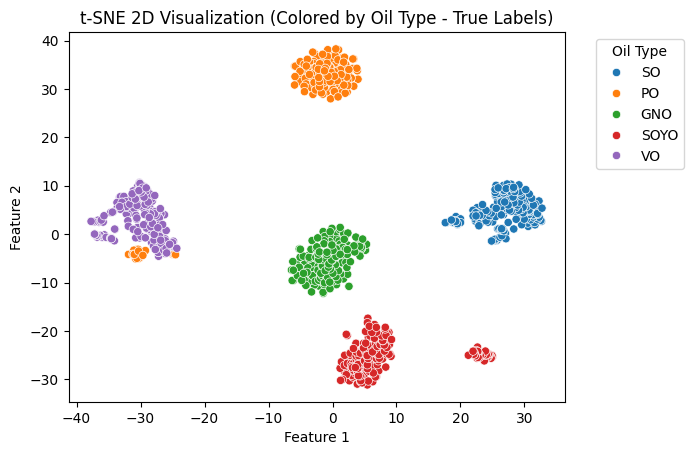

In [13]:
# #Add true labels 
tsne_2d_data = tsne_2d_data.copy()
tsne_2d_data["Oil_Type"] = y.reset_index(drop = True)

#Plot with colors = oil type
sns.scatterplot(
    data = tsne_2d_data,
    x = "Feature 1",
    y = "Feature 2",
    hue = "Oil_Type",
    palette=palette
    #palette = "tab10"
)
plt.legend(title = "Oil Type", loc="upper left",bbox_to_anchor = (1.05,1))
plt.title("t-SNE 2D Visualization (Colored by Oil Type - True Labels)")
plt.savefig(r"Images\K-Means Clusters\tsne_plot_default_oils.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()

In [14]:
# Let us check the default perplexity. Perplexity is the number of neighbors influencing each point
print(TSNE().get_params()["perplexity"])

30.0


### We see VO and PO oils similar. Let us check at different perplexities

### t‑SNE sensitivity to perplexity: Multiple 2D views at different perplexities to check stability of local neighborhoods.

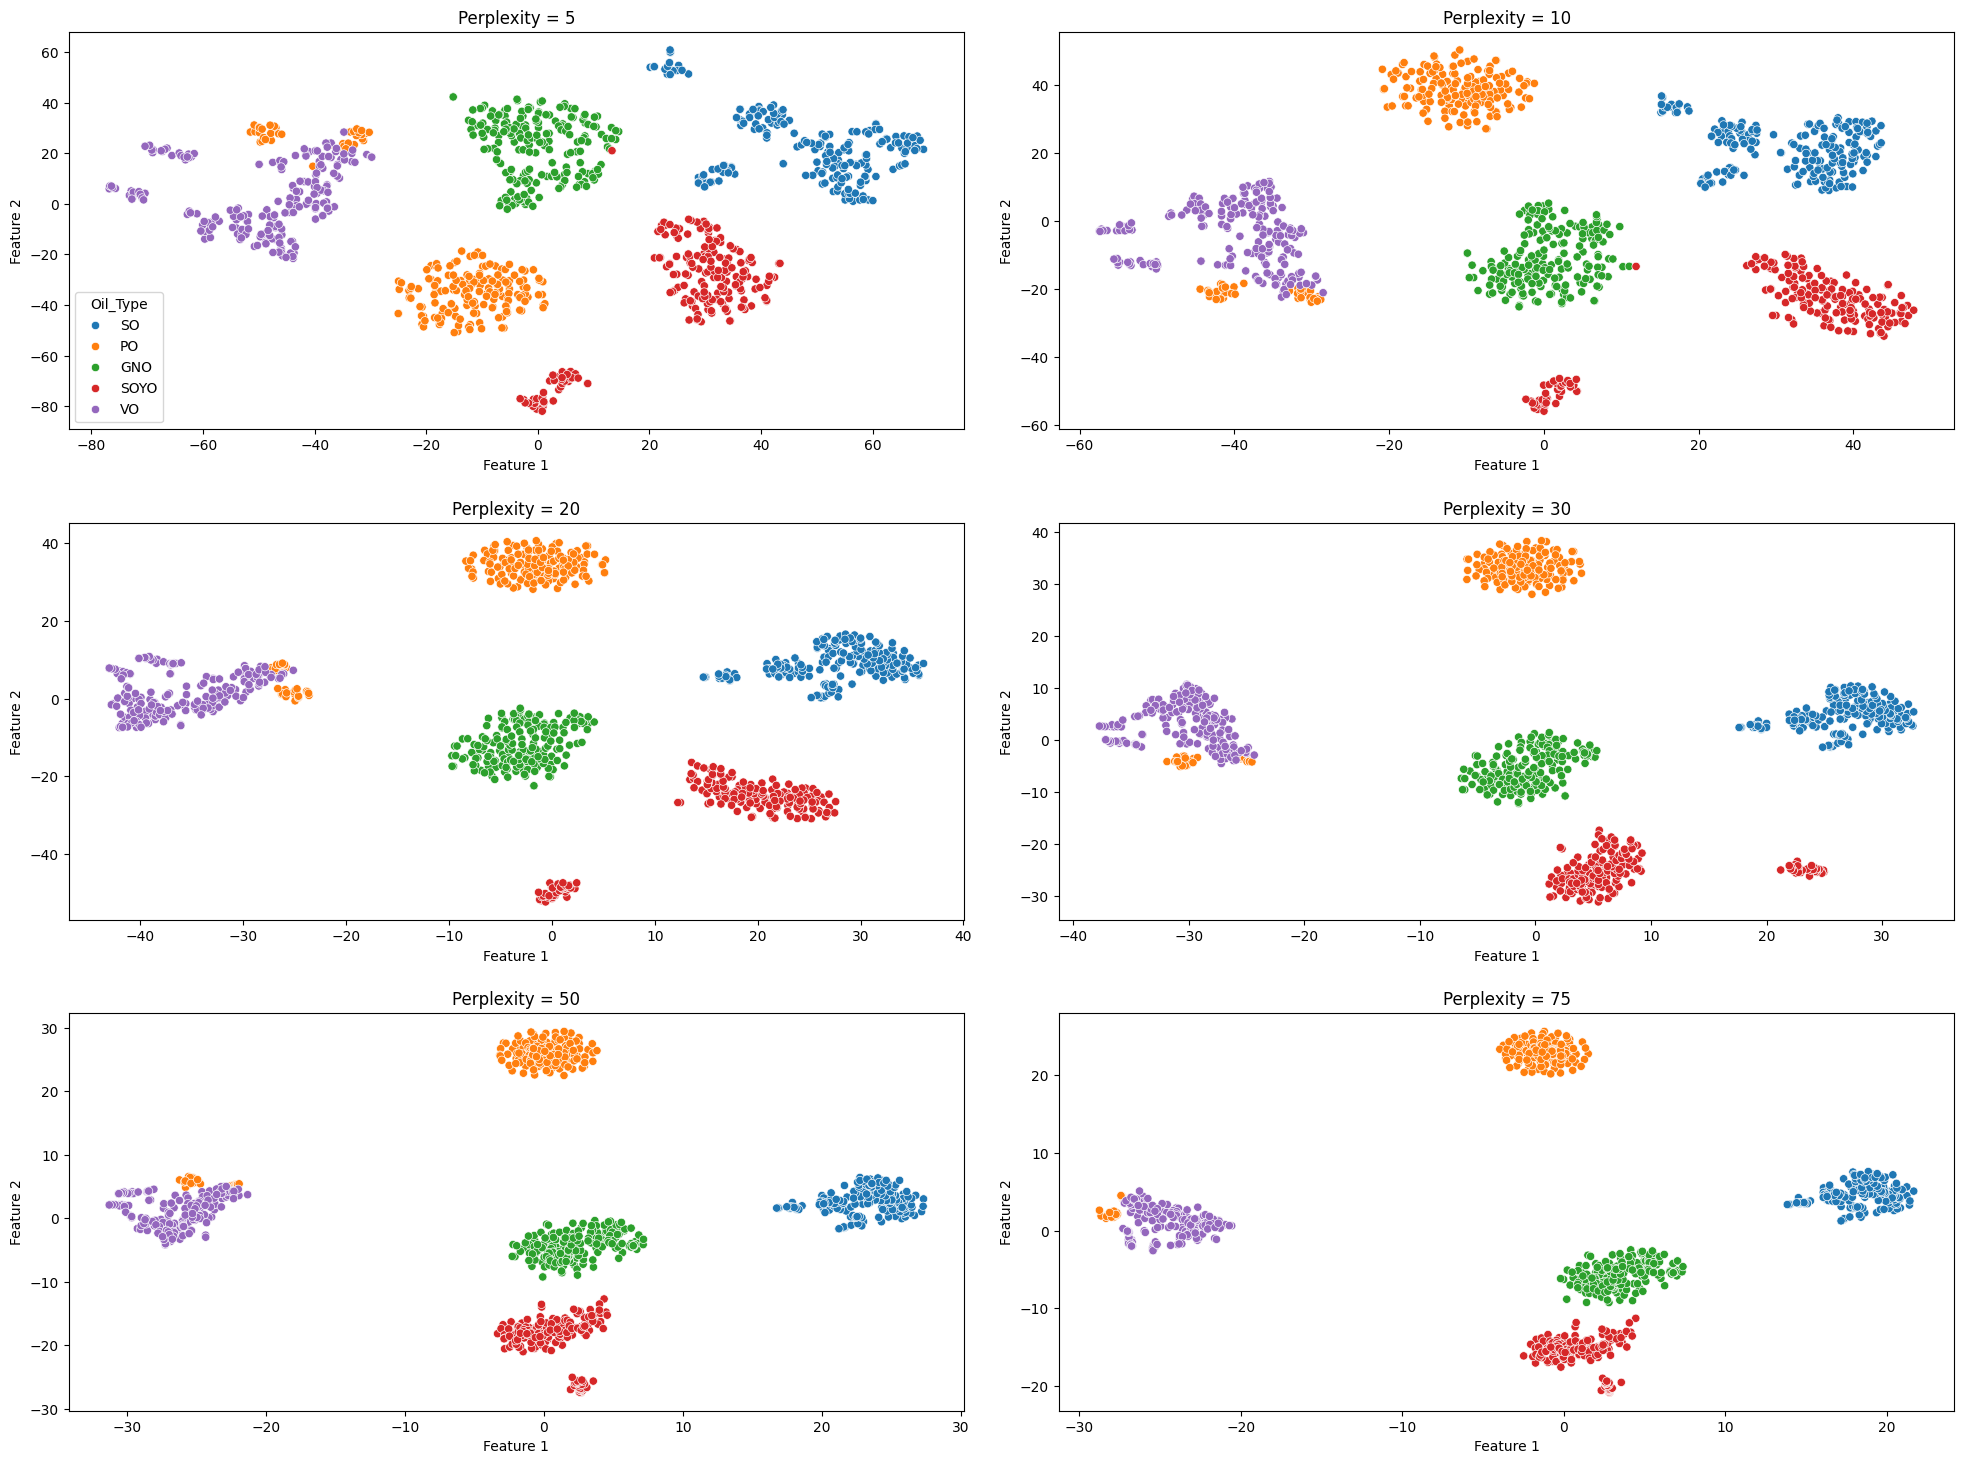

In [15]:
hue_order = ["SO", "PO", "GNO", "SOYO", "VO"]

# Define the list of perplexity values to iterate over
perplexities = [5, 10, 20, 30, 50, 75]

plt.figure(figsize=(20, 15))

for i in range(len(perplexities)):

    tsne = TSNE(
        n_components=2,
        perplexity=perplexities[i],
        n_jobs=-2,
        random_state=RS
    )

    X_red = tsne.fit_transform(subset_scaled_df)

    red_data_df = pd.DataFrame(
        data=X_red,
        columns=["Feature 1", "Feature 2"]
    )

    red_data_df["Oil_Type"] = y.reset_index(drop=True)

    plt.subplot(3, 2, i + 1)

    sns.scatterplot(
        data=red_data_df,
        x="Feature 1",
        y="Feature 2",
        hue="Oil_Type",
        hue_order=hue_order,
        palette=palette
    )

    plt.title(f"Perplexity = {perplexities[i]}")

    # Optional: show legend only on first plot
    if i != 0:
        plt.legend([], [], frameon=False)

plt.tight_layout(pad=2)
plt.savefig(r"Images\K-Means Clusters\tsne_perplexity_grid_oils.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()

###  t‑SNE to 2D & 3D (fixed perplexity=50): Produce 2D and 3D embeddings; preview few rows.

In [16]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions
tsne_2d_data.head(2)

,Feature 1,Feature 2
0,22.995325,-0.506512
1,24.284687,-0.523216


In [17]:
# Add oil labels to t-SNE data
tsne_2d_data ["Oil_Type"] = y.reset_index(drop = True)
# Save to CSV
tsne_2d_data.to_csv(r"Images\K-Means Clusters\tsne_2d_data_with_oils.csv", index = False)

In [18]:
# Read CSV file
df_check = pd.read_csv(r"Images\K-Means Clusters\tsne_2d_data_with_oils.csv")
print(df_check.columns)
print(df_check.shape)
print(df_check.nunique())
print(df_check.head())

Index(['Feature 1', 'Feature 2', 'Oil_Type'], dtype='object')
(1000, 3)
Feature 1    1000
Feature 2    1000
Oil_Type        5
dtype: int64
   Feature 1  Feature 2 Oil_Type
0  22.995325  -0.506512       SO
1  24.284687  -0.523216       SO
2  24.091206   0.172663       SO
3  25.748451  -0.038380       SO
4  27.173336   1.072502       SO


In [19]:
# Group oil type and obtain min/max ranges:
range_df = tsne_2d_data.groupby("Oil_Type").agg({"Feature 1": ["min", "max"],"Feature 2": ["min", "max"]})
print(range_df)

          Feature 1             Feature 2           
                min        max        min        max
Oil_Type                                            
GNO       -2.269889   7.171690  -9.209670  -0.334803
PO       -26.199289   3.824615   4.885622  29.433376
SO        16.749929  27.314007  -1.620288   6.450628
SOYO      -3.324098   4.563796 -27.425371 -12.675283
VO       -31.253960 -21.300253  -4.155339   5.037352


### Let us check it in 3D space

In [20]:
# Initiating the TSNE object and setting output dimension to 3
# n_components=3 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one core for parallel computation, which speeds up the process
tsne = TSNE(n_components=3, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_3d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2","Feature 3"])) # This DataFrame will have three columns corresponding to the three reduced dimensions

In [21]:
tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3
0,-1.091745,-0.650866,9.537839
1,1.290768,-0.991182,11.078765
2,-0.872748,-0.678012,10.836936
3,-1.498726,-0.727551,11.819371
4,-2.066379,0.316689,10.687423


In [22]:
# Add oil labels to the 3D t-SNE dataframe
tsne_3d_data["Oil_Type"] = y.reset_index(drop=True)

# Optional: move Oil_Type to the first column
cols = ["Oil_Type", "Feature 1", "Feature 2", "Feature 3"]
tsne_3d_data = tsne_3d_data[cols]

# Check the result
display(tsne_3d_data.head())

# Save as CSV
tsne_3d_data.to_csv(r"Images\K-Means Clusters\tsne_3d_with_oil_labels.csv", index=False)

print("CSV saved as: tsne_3d_with_oil_labels.csv")

,Oil_Type,Feature 1,Feature 2,Feature 3
0,SO,-1.091745,-0.650866,9.537839
1,SO,1.290768,-0.991182,11.078765
2,SO,-0.872748,-0.678012,10.836936
3,SO,-1.498726,-0.727551,11.819371
4,SO,-2.066379,0.316689,10.687423


CSV saved as: tsne_3d_with_oil_labels.csv


In [23]:
# Read CSV file
df_check = pd.read_csv(r"Images\K-Means Clusters\tsne_3d_with_oil_labels.csv")
print(df_check.columns)
print(df_check.shape)
print(df_check.nunique())
print(df_check.head())

Index(['Oil_Type', 'Feature 1', 'Feature 2', 'Feature 3'], dtype='object')
(1000, 4)
Oil_Type       5
Feature 1    999
Feature 2    999
Feature 3    999
dtype: int64
  Oil_Type  Feature 1  Feature 2  Feature 3
0       SO  -1.091745  -0.650866   9.537839
1       SO   1.290768  -0.991182  11.078765
2       SO  -0.872748  -0.678012  10.836936
3       SO  -1.498726  -0.727551  11.819371
4       SO  -2.066379   0.316689  10.687423


In [24]:
# Group oil type and obtain min/max ranges:
range_df = tsne_3d_data.groupby("Oil_Type").agg({"Feature 1": ["min", "max"],"Feature 2": ["min", "max"],"Feature 3": ["min", "max"]})
print(range_df)

          Feature 1             Feature 2            Feature 3           
                min        max        min        max       min        max
Oil_Type                                                                 
GNO        4.620943  11.419684  -4.791718   2.392878 -4.296143   3.625045
PO        -7.907784   3.864364   0.057195  14.169704 -6.317717   1.214775
SO        -2.162339   4.366228  -2.227424   4.859221  6.818290  13.583636
SOYO      -4.317416   4.609278 -11.266180  -4.110756 -7.531781   0.890495
VO       -13.796448  -5.065292  -3.519399   4.278240 -2.760868   1.679949


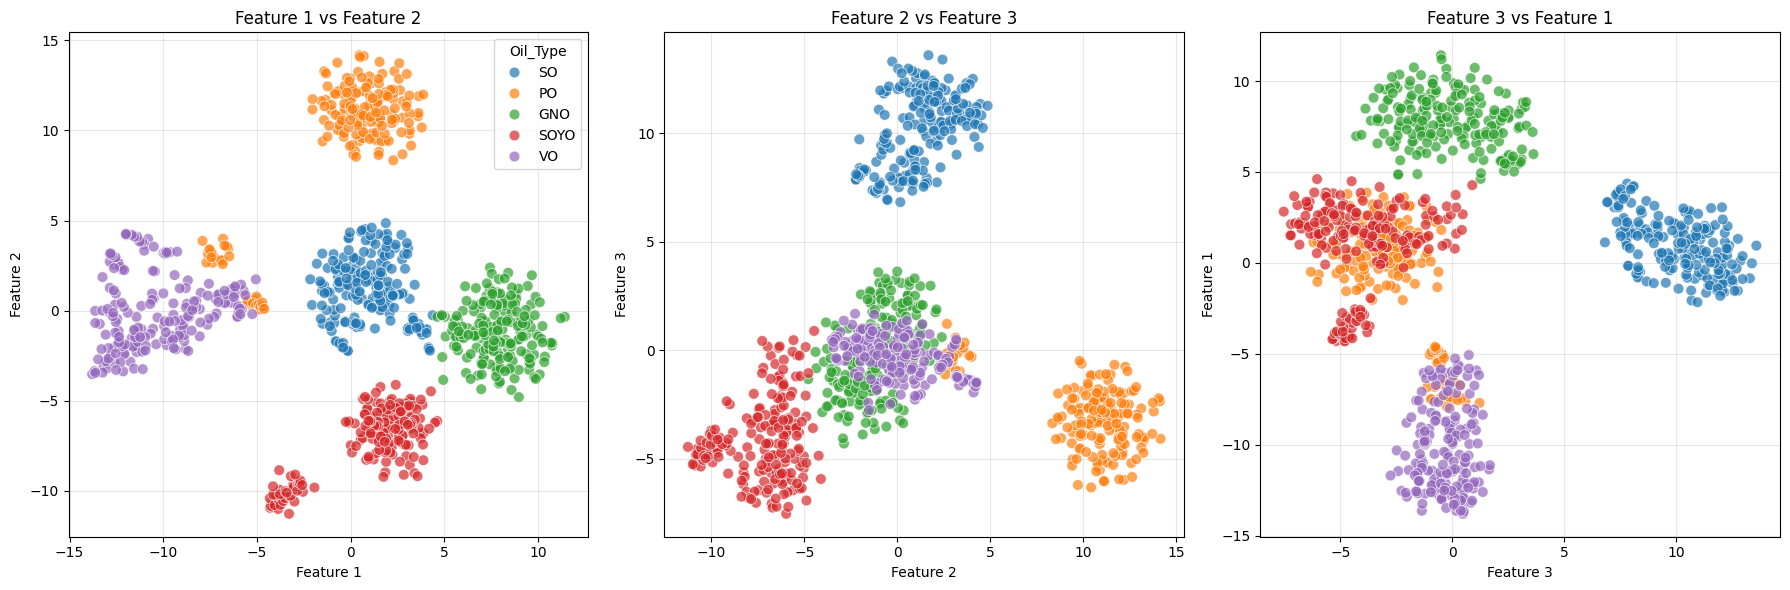

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Feature 1 vs Feature 2
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 1",
    y="Feature 2",
    hue="Oil_Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[0]
)

axes[0].set_title("Feature 1 vs Feature 2")
axes[0].grid(alpha=0.3)

# Feature 2 vs Feature 3
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 2",
    y="Feature 3",
    hue="Oil_Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[1]
)

axes[1].set_title("Feature 2 vs Feature 3")
axes[1].grid(alpha=0.3)

# Feature 3 vs Feature 1
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 3",
    y="Feature 1",
    hue="Oil_Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[2]
)

axes[2].set_title("Feature 3 vs Feature 1")
axes[2].grid(alpha=0.3)

# Keep only one legend
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.tight_layout()

plt.savefig(r"Images\K-Means Clusters\tsne_3d_pairwise_projections_Oils.png",dpi=300,bbox_inches="tight")
plt.show()

In [26]:
palette = {
    "SO": "blue",
    "PO": "orange",
    "GNO": "green",
    "SOYO": "red",
    "VO": "purple"
}
# Add TRUE labels to 3D t-SNE
tsne_3d_data["True_Label"] = y.values

fig = px.scatter_3d(
    tsne_3d_data,
    x="Feature 1",
    y="Feature 2",
    z="Feature 3",
    color="True_Label",
    color_discrete_map=palette,
    title="t-SNE 3D (True Labels)"
)

fig.write_image(r"Images\K-Means Clusters\tsne_3d_oils_plot.jpg")
fig.show()

In [27]:
k_means_df = subset_scaled_df.copy()

### Elbow (WCSS) across k=2..10: Fit K‑means and record inertia to eyeball elbow.

In [28]:
clusters = range(2, 11)
WCSS = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=RS)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)

    wcss = model.inertia_


    WCSS.append(wcss)

    print("Number of Clusters:", k, "\twcss:", wcss)

Number of Clusters: 2 	wcss: 1014415.2718695082
Number of Clusters: 3 	wcss: 804205.7086615245
Number of Clusters: 4 	wcss: 684060.6531170994
Number of Clusters: 5 	wcss: 615065.2034178884
Number of Clusters: 6 	wcss: 600439.9955930662


Number of Clusters: 7 	wcss: 577937.9512187561
Number of Clusters: 8 	wcss: 575245.8027509422
Number of Clusters: 9 	wcss: 562727.844721164
Number of Clusters: 10 	wcss: 559004.4863910757


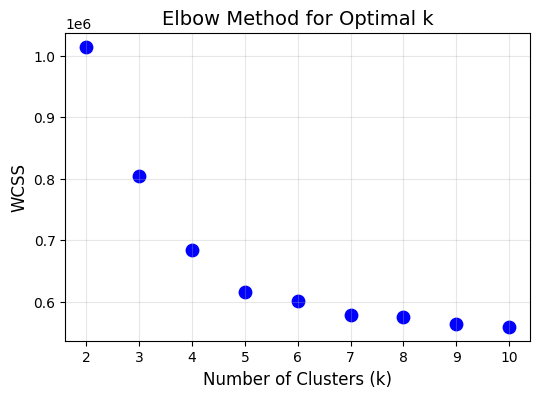

In [29]:
plt.figure(figsize=(6,4))

plt.scatter(
    clusters,
    WCSS,
    s=80,           # marker size
    color='blue',
    marker='o'
)

plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("WCSS", fontsize=12)
plt.title("Elbow Method for Optimal k", fontsize=14)

plt.xticks(clusters)
plt.grid(alpha=0.3)
plt.savefig(r"Images\K-Means Clusters\elbow_plot_oils.jpg",dpi=300,bbox_inches='tight')
plt.show()

In [30]:
K_Means = []
WCSS_Oils = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RS)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)

    wcss = model.inertia_

    K_Means.append(k)
    WCSS_Oils.append(wcss)

print("K-Means:", K_Means)
print("WCSS_Oils:", WCSS_Oils)

K-Means: [2, 3, 4, 5, 6, 7, 8, 9, 10]
WCSS_Oils: [1014415.2718695082, 804205.7086615245, 684060.6531170994, 615065.2034178884, 600439.9955930662, 577937.9512187561, 575245.8027509422, 562727.844721164, 559004.4863910757]


### Creating a combined plot for Oils and Chips (from another notebook)

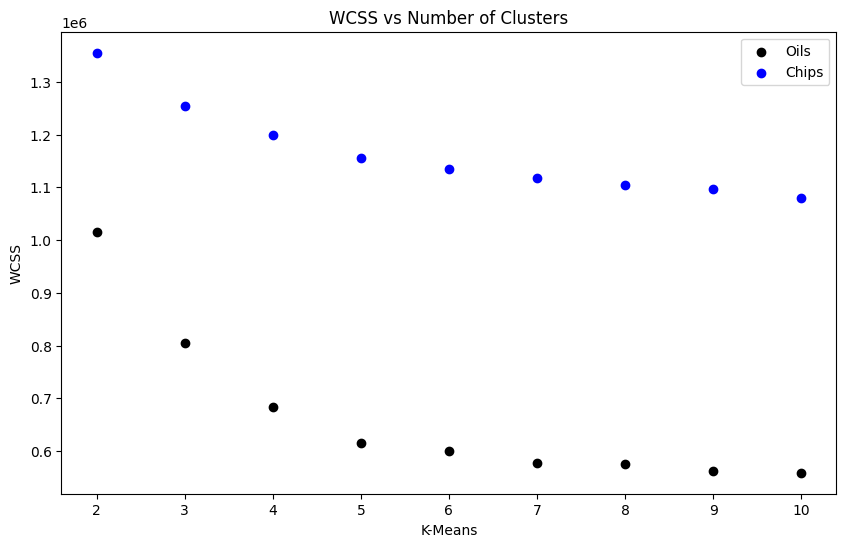

In [31]:
K_Means= [2, 3, 4, 5, 6, 7, 8, 9, 10]
WCSS_Oils = [1014415.2718695084, 804205.7086615243, 684060.6531170994, 615065.2034178884, 600439.9955930661, 577937.951218756, 575245.8027509423, 562727.844721164, 559004.4863910757]
WCSS_Chips = [1355223.2647472555, 1255060.0997165395, 1199992.8010902007, 1155489.4535949598, 1134303.8699853644, 1116806.2909579375, 1105317.4975468433, 1097759.4043528698, 1079099.9776593682]

plt.figure(figsize=(10, 6))

plt.scatter(K_Means, WCSS_Oils, color='black', label='Oils')
plt.scatter(K_Means, WCSS_Chips, color='blue', label='Chips')

plt.xlabel('K-Means')
plt.ylabel('WCSS')
plt.title('WCSS vs Number of Clusters')

plt.xticks(K_Means)
plt.legend()
#plt.grid(True)
plt.savefig(r"Images\K-Means Clusters\K-Clusters-Combined.jpg",dpi=300,bbox_inches='tight')
plt.show()

### Compute silhouette scores for k=2..9 and plot them to complement elbow.

In [32]:
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=RS)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, the silhouette score is 0.46313868856165374)
For n_clusters = 3, the silhouette score is 0.33085187586939774)
For n_clusters = 4, the silhouette score is 0.3331391137115926)
For n_clusters = 5, the silhouette score is 0.34343594333052574)
For n_clusters = 6, the silhouette score is 0.34743753284741585)


For n_clusters = 7, the silhouette score is 0.3293624811515342)
For n_clusters = 8, the silhouette score is 0.20068062221203092)
For n_clusters = 9, the silhouette score is 0.20423627316184842)


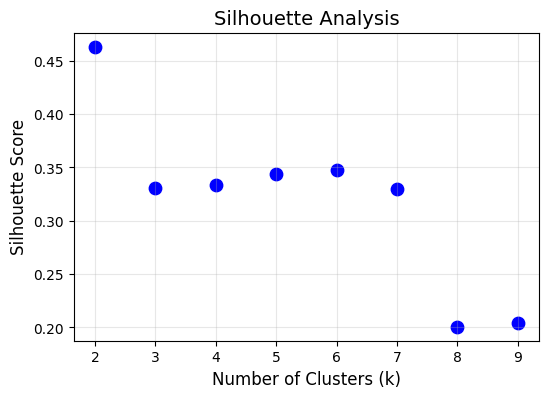

In [33]:
plt.figure(figsize=(6,4))

plt.scatter(
    cluster_list,
    sil_score,
    s=80,
    color='blue',
    marker='o'
)

plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Analysis", fontsize=14)

plt.xticks(cluster_list)
plt.grid(alpha=0.3)

plt.savefig(r"Images\K-Means Clusters\silhouette_oils_plot.jpg", dpi=300, bbox_inches='tight')

plt.show()

In [34]:
n_clusters = list(range(2, 10))
sil_oil = []

for n_cluster in n_clusters:
    clusterer = KMeans(n_clusters=n_cluster, random_state=RS)
    preds = clusterer.fit_predict(subset_scaled_df)
    score = silhouette_score(k_means_df, preds)
    sil_oil.append(score)

    print("For n_clusters = {}, the silhouette score is {}".format(n_cluster, score))

print("n_clusters:", n_clusters)
print("sil_oil:", sil_oil)

For n_clusters = 2, the silhouette score is 0.46313868856165374
For n_clusters = 3, the silhouette score is 0.33085187586939774
For n_clusters = 4, the silhouette score is 0.3331391137115926
For n_clusters = 5, the silhouette score is 0.34343594333052574


For n_clusters = 6, the silhouette score is 0.34743753284741585
For n_clusters = 7, the silhouette score is 0.3293624811515342
For n_clusters = 8, the silhouette score is 0.20068062221203092
For n_clusters = 9, the silhouette score is 0.20423627316184842
n_clusters: [2, 3, 4, 5, 6, 7, 8, 9]
sil_oil: [0.46313868856165374, 0.33085187586939774, 0.3331391137115926, 0.34343594333052574, 0.34743753284741585, 0.3293624811515342, 0.20068062221203092, 0.20423627316184842]


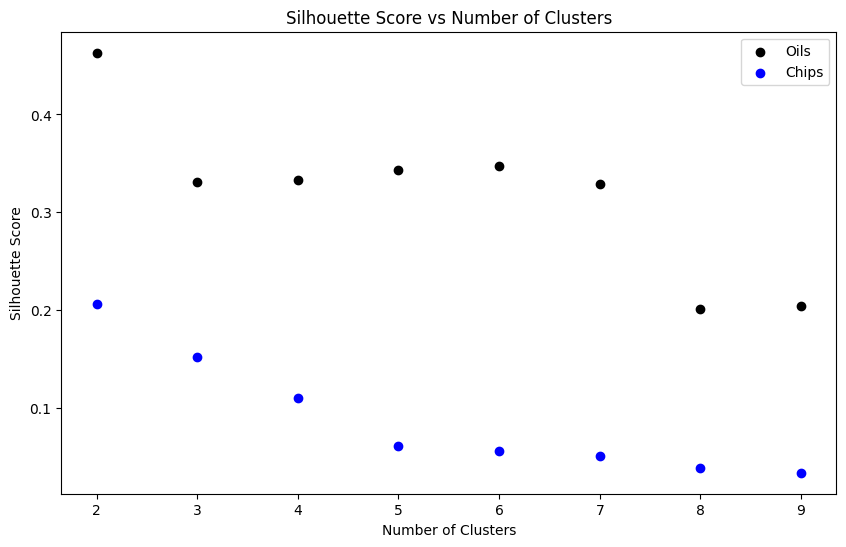

In [35]:
n_clusters= [2, 3, 4, 5, 6, 7, 8, 9]
sil_oil= [0.46313868856166096, 0.33085187586942405, 0.333139113711639, 0.3434359433305765, 0.34743753284746676, 0.3293624811515904, 0.2006806222120871, 0.20423627316190465]
sil_chips = [0.20630888811831213, 0.15160265710718807, 0.11041064216952307, 0.06136362459289905, 0.055962000116054525, 0.050724992082535995, 0.038900880231104, 0.033737002828540454]

plt.figure(figsize=(10, 6))
plt.scatter(n_clusters, sil_oil, color='black', label='Oils')
plt.scatter(n_clusters, sil_chips, color='blue', label='Chips')

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')

plt.xticks(n_clusters)
plt.legend()
#plt.grid(True)
plt.savefig(r"Images\K-Means Clusters\silhouette_combined.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# Ensure column names are strings (required by sklearn sometimes)
k_means_df.columns = k_means_df.columns.astype(str)
# -------- K-MEANS MODEL --------
kmeans = KMeans(n_clusters=5, random_state=RS)
kmeans.fit(k_means_df)

# -------- CREATE COPIES --------
df1 = df.copy()   # original (unscaled); Z-scores, negative values kept as-is

In [37]:
# -------- ASSIGN CLUSTERS --------
# scaled high-dimensional data (k_means_df) to which we are adding a new column and assigning labels. 
#Each data point is tagged with its cluster now
k_means_df["K_means_segments"] = kmeans.labels_    
df1["K_means_segments"] = kmeans.labels_             # original unscaled data to which same cluster labels are added
tsne_2d_data["K_means_segments"] = kmeans.labels_    # t-SNE 2D data tagged with cluster labels
tsne_3d_data["K_means_segments"] = kmeans.labels_    # t-SNE 3D data tagged with cluster labels

In [38]:
# Map cluster number -> oil name
cluster_map = pd.crosstab(y, kmeans.labels_).idxmax()

# Convert to dictionary
mapping = cluster_map.to_dict()

# Create cluster labels
tsne_2d_data["Cluster_Label"] = pd.Series(kmeans.labels_).map(mapping)

print(tsne_2d_data["Cluster_Label"].value_counts())

Cluster_Label
VO      240
GNO     218
SO      200
SOYO    182
PO      160
Name: count, dtype: int64


### From the above, K-Means clusters are not perfectly aligned with the true oil labels. The overlap between PO and VO can be observed here.

In [39]:
# 1. Cross-tabulation (MOST IMPORTANT)
cluster_vs_label = pd.crosstab(y, kmeans.labels_, margins=True)
print("\n=== Cluster vs True Label Comparison ===")
print(cluster_vs_label)
# 2. Dominant cluster per oil type (optional but very important)
dominant_cluster = cluster_vs_label.drop("All", axis=1).idxmax(axis=1)
print("\n=== Dominant Cluster for Each Oil Type ===")
print(dominant_cluster)
# 3. (OPTIONAL) Add TRUE labels to t-SNE for visual validation
tsne_2d_data["True_Label"] = y.values


=== Cluster vs True Label Comparison ===
col_0    0    1    2    3    4   All
Oil                                 
GNO    200    0    0    0    0   200
PO       0   40  160    0    0   200
SO       0    0    0  200    0   200
SOYO    18    0    0    0  182   200
VO       0  200    0    0    0   200
All    218  240  160  200  182  1000

=== Dominant Cluster for Each Oil Type ===
Oil
GNO     0
PO      2
SO      3
SOYO    4
VO      1
All     1
dtype: object


In [40]:
print(tsne_2d_data.columns)

Index(['Feature 1', 'Feature 2', 'Oil_Type', 'K_means_segments',
       'Cluster_Label', 'True_Label'],
      dtype='object')


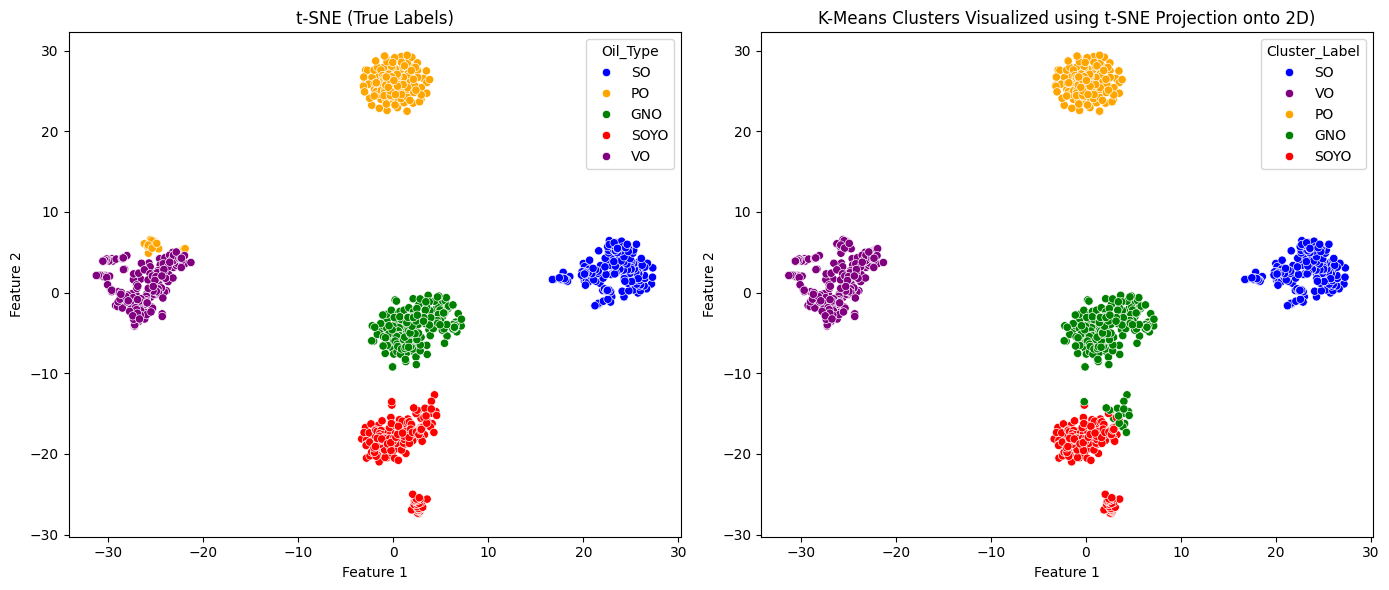

In [41]:
# Plot TRUE label vs CLUSTER comparison side-by-side
plt.figure(figsize=(14,6))
# TRUE LABELS
plt.subplot(1,2,1)
sns.scatterplot(
    data=tsne_2d_data,
    x="Feature 1",
    y="Feature 2",
    #hue="True_Label",
    hue="Oil_Type",
    palette=palette
    #palette="tab10"
)
plt.title("t-SNE (True Labels)")
# CLUSTERS
plt.subplot(1,2,2)
sns.scatterplot(
    data=tsne_2d_data,
    x="Feature 1",
    y="Feature 2",
    #hue="K_means_segments",
    hue="Cluster_Label",
    #palette="tab10"
    palette=palette
)
plt.title("K-Means Clusters Visualized using t-SNE Projection onto 2D)")
plt.tight_layout()
plt.savefig(r"Images\K-Means Clusters\kmeans_tsne_clusters_oils.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()

###  Attach cluster labels back to data and visualize on t‑SNE and append `K_means_segments` and produce 2D/3D plots with color by cluster.

In [42]:
# Create Cluster Profile: Mean spectra per cluster (Average spectral profile of the clusters)
km_cluster_profile = df1.groupby("K_means_segments").mean(numeric_only = True)
km_cluster_profile 

500.8563  501.8205  502.7847   503.749  504.7132  505.6774  \
K_means_segments                                                               
0                -0.442460 -0.331334 -0.231612 -0.204361 -0.226111 -0.265087   
1                -0.663284 -0.873819 -0.906580 -0.922437 -0.944164 -0.939328   
2                 0.295132  0.421010  0.495620  0.578761  0.674461  0.747494   
3                 0.491627  0.449883  0.369045  0.337456  0.345784  0.368468   
4                 0.604934  0.684666  0.631661  0.581553  0.542973  0.494150   

                  506.6417  507.6059  508.5701  509.5344  510.4986  511.4628  \
K_means_segments                                                               
0                -0.268911 -0.248085 -0.193875 -0.101210  0.023680  0.153747   
1                -0.938481 -0.951469 -0.969401 -0.985872 -1.004437 -1.034641   
2                 0.784837  0.789606  0.743251  0.647844  0.540715  0.465706   
3                 0.385288  0.409697  0.424707  0.404357  0.327832  0.210837   
4                 0.446300  0.407465  0.390435  0.407399  0.460560  0.539102   

                  512.4271  513.3913  514.3555  515.3198   516.284  517.2482  \
K_means_segments                                                               
0                 0.224796  0.233611  0.206513  0.185734  0.201958  0.261962   
1                -1.061092 -1.080310 -1.096460 -1.109988 -1.136014 -1.165947   
2                 0.449394  0.487997  0.567623  0.652247  0.718354  0.741607   
3                 0.113547  0.055156  0.029272  0.022447  0.026694  0.032003   
4                 0.610132  0.655146  0.667344  0.643177  0.595281  0.536604   

                  518.2125  519.1767  520.1409  521.1052  522.0694  523.0336  \
K_means_segments                                                               
0                 0.357018  0.468065  0.564514  0.628494  0.664538  0.682568   
1                -1.182163 -1.182392 -1.168215 -1.149231 -1.136458 -1.119731   
2                 0.709725  0.645656  0.586513  0.552337  0.544821  0.550226   
3                 0.026284  0.007973 -0.013796 -0.036974 -0.068588 -0.108666   
4                 0.478441  0.422177  0.363872  0.317718  0.299049  0.294685   

                  523.9979  524.9621  525.9263  526.8906  527.8548   528.819  \
K_means_segments                                                               
0                 0.687044  0.677717  0.675450  0.705957  0.763133  0.828559   
1                -1.106183 -1.092678 -1.075358 -1.062952 -1.049394 -1.032000   
2                 0.577352  0.618589  0.637883  0.615674  0.563187  0.513816   
3                -0.142351 -0.152184 -0.152231 -0.163815 -0.194341 -0.240704   
4                 0.284628  0.252544  0.215509  0.194863  0.188186  0.181232   

                  529.7833  530.7475  531.7117   532.676  533.6402  534.6044  \
K_means_segments                                                               
0                 0.886290  0.930067  0.963347  0.973251  0.956270  0.934260   
1                -1.008101 -0.977768 -0.947479 -0.912712 -0.874226 -0.846400   
2                 0.484918  0.468128  0.449156  0.425196  0.410379  0.413970   
3                -0.298086 -0.365572 -0.438560 -0.494278 -0.513951 -0.504779   
4                 0.169029  0.165514  0.182596  0.207179  0.211412  0.187847   

                  535.5687  536.5329  537.4971  538.4614  539.4256  540.3898  \
K_means_segments                                                               
0                 0.921459  0.928109  0.945689  0.955786  0.961790  0.961482   
1                -0.818183 -0.785420 -0.745219 -0.696530 -0.650849 -0.605685   
2                 0.401221  0.352087  0.279910  0.225513  0.221282  0.256011   
3                -0.490900 -0.494475 -0.523328 -0.569975 -0.632470 -0.702010   
4                 0.161926  0.157878  0.178969  0.201750  0.206716  0.193416   

                  541.3541  542.3183  543.2825  544.2468   545.211  546.1752  \
K_means_seg

In [43]:
# Add count of points in each cluster: 
km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("K_means_segments").size().values)

# Display profile
km_cluster_profile

500.8563  501.8205  502.7847   503.749  504.7132  505.6774  \
K_means_segments                                                               
0                -0.442460 -0.331334 -0.231612 -0.204361 -0.226111 -0.265087   
1                -0.663284 -0.873819 -0.906580 -0.922437 -0.944164 -0.939328   
2                 0.295132  0.421010  0.495620  0.578761  0.674461  0.747494   
3                 0.491627  0.449883  0.369045  0.337456  0.345784  0.368468   
4                 0.604934  0.684666  0.631661  0.581553  0.542973  0.494150   

                  506.6417  507.6059  508.5701  509.5344  510.4986  511.4628  \
K_means_segments                                                               
0                -0.268911 -0.248085 -0.193875 -0.101210  0.023680  0.153747   
1                -0.938481 -0.951469 -0.969401 -0.985872 -1.004437 -1.034641   
2                 0.784837  0.789606  0.743251  0.647844  0.540715  0.465706   
3                 0.385288  0.409697  0.424707  0.404357  0.327832  0.210837   
4                 0.446300  0.407465  0.390435  0.407399  0.460560  0.539102   

                  512.4271  513.3913  514.3555  515.3198   516.284  517.2482  \
K_means_segments                                                               
0                 0.224796  0.233611  0.206513  0.185734  0.201958  0.261962   
1                -1.061092 -1.080310 -1.096460 -1.109988 -1.136014 -1.165947   
2                 0.449394  0.487997  0.567623  0.652247  0.718354  0.741607   
3                 0.113547  0.055156  0.029272  0.022447  0.026694  0.032003   
4                 0.610132  0.655146  0.667344  0.643177  0.595281  0.536604   

                  518.2125  519.1767  520.1409  521.1052  522.0694  523.0336  \
K_means_segments                                                               
0                 0.357018  0.468065  0.564514  0.628494  0.664538  0.682568   
1                -1.182163 -1.182392 -1.168215 -1.149231 -1.136458 -1.119731   
2                 0.709725  0.645656  0.586513  0.552337  0.544821  0.550226   
3                 0.026284  0.007973 -0.013796 -0.036974 -0.068588 -0.108666   
4                 0.478441  0.422177  0.363872  0.317718  0.299049  0.294685   

                  523.9979  524.9621  525.9263  526.8906  527.8548   528.819  \
K_means_segments                                                               
0                 0.687044  0.677717  0.675450  0.705957  0.763133  0.828559   
1                -1.106183 -1.092678 -1.075358 -1.062952 -1.049394 -1.032000   
2                 0.577352  0.618589  0.637883  0.615674  0.563187  0.513816   
3                -0.142351 -0.152184 -0.152231 -0.163815 -0.194341 -0.240704   
4                 0.284628  0.252544  0.215509  0.194863  0.188186  0.181232   

                  529.7833  530.7475  531.7117   532.676  533.6402  534.6044  \
K_means_segments                                                               
0                 0.886290  0.930067  0.963347  0.973251  0.956270  0.934260   
1                -1.008101 -0.977768 -0.947479 -0.912712 -0.874226 -0.846400   
2                 0.484918  0.468128  0.449156  0.425196  0.410379  0.413970   
3                -0.298086 -0.365572 -0.438560 -0.494278 -0.513951 -0.504779   
4                 0.169029  0.165514  0.182596  0.207179  0.211412  0.187847   

                  535.5687  536.5329  537.4971  538.4614  539.4256  540.3898  \
K_means_segments                                                               
0                 0.921459  0.928109  0.945689  0.955786  0.961790  0.961482   
1                -0.818183 -0.785420 -0.745219 -0.696530 -0.650849 -0.605685   
2                 0.401221  0.352087  0.279910  0.225513  0.221282  0.256011   
3                -0.490900 -0.494475 -0.523328 -0.569975 -0.632470 -0.702010   
4                 0.161926  0.157878  0.178969  0.201750  0.206716  0.193416   

                  541.3541  542.3183  543.2825  544.2468   545.211  546.1752  \
K_means_seg

In [44]:
km_cluster_profile.index = km_cluster_profile.index.map(mapping)

km_cluster_profile

500.8563  501.8205  502.7847   503.749  504.7132  505.6774  \
K_means_segments                                                               
GNO              -0.442460 -0.331334 -0.231612 -0.204361 -0.226111 -0.265087   
VO               -0.663284 -0.873819 -0.906580 -0.922437 -0.944164 -0.939328   
PO                0.295132  0.421010  0.495620  0.578761  0.674461  0.747494   
SO                0.491627  0.449883  0.369045  0.337456  0.345784  0.368468   
SOYO              0.604934  0.684666  0.631661  0.581553  0.542973  0.494150   

                  506.6417  507.6059  508.5701  509.5344  510.4986  511.4628  \
K_means_segments                                                               
GNO              -0.268911 -0.248085 -0.193875 -0.101210  0.023680  0.153747   
VO               -0.938481 -0.951469 -0.969401 -0.985872 -1.004437 -1.034641   
PO                0.784837  0.789606  0.743251  0.647844  0.540715  0.465706   
SO                0.385288  0.409697  0.424707  0.404357  0.327832  0.210837   
SOYO              0.446300  0.407465  0.390435  0.407399  0.460560  0.539102   

                  512.4271  513.3913  514.3555  515.3198   516.284  517.2482  \
K_means_segments                                                               
GNO               0.224796  0.233611  0.206513  0.185734  0.201958  0.261962   
VO               -1.061092 -1.080310 -1.096460 -1.109988 -1.136014 -1.165947   
PO                0.449394  0.487997  0.567623  0.652247  0.718354  0.741607   
SO                0.113547  0.055156  0.029272  0.022447  0.026694  0.032003   
SOYO              0.610132  0.655146  0.667344  0.643177  0.595281  0.536604   

                  518.2125  519.1767  520.1409  521.1052  522.0694  523.0336  \
K_means_segments                                                               
GNO               0.357018  0.468065  0.564514  0.628494  0.664538  0.682568   
VO               -1.182163 -1.182392 -1.168215 -1.149231 -1.136458 -1.119731   
PO                0.709725  0.645656  0.586513  0.552337  0.544821  0.550226   
SO                0.026284  0.007973 -0.013796 -0.036974 -0.068588 -0.108666   
SOYO              0.478441  0.422177  0.363872  0.317718  0.299049  0.294685   

                  523.9979  524.9621  525.9263  526.8906  527.8548   528.819  \
K_means_segments                                                               
GNO               0.687044  0.677717  0.675450  0.705957  0.763133  0.828559   
VO               -1.106183 -1.092678 -1.075358 -1.062952 -1.049394 -1.032000   
PO                0.577352  0.618589  0.637883  0.615674  0.563187  0.513816   
SO               -0.142351 -0.152184 -0.152231 -0.163815 -0.194341 -0.240704   
SOYO              0.284628  0.252544  0.215509  0.194863  0.188186  0.181232   

                  529.7833  530.7475  531.7117   532.676  533.6402  534.6044  \
K_means_segments                                                               
GNO               0.886290  0.930067  0.963347  0.973251  0.956270  0.934260   
VO               -1.008101 -0.977768 -0.947479 -0.912712 -0.874226 -0.846400   
PO                0.484918  0.468128  0.449156  0.425196  0.410379  0.413970   
SO               -0.298086 -0.365572 -0.438560 -0.494278 -0.513951 -0.504779   
SOYO              0.169029  0.165514  0.182596  0.207179  0.211412  0.187847   

                  535.5687  536.5329  537.4971  538.4614  539.4256  540.3898  \
K_means_segments                                                               
GNO               0.921459  0.928109  0.945689  0.955786  0.961790  0.961482   
VO               -0.818183 -0.785420 -0.745219 -0.696530 -0.650849 -0.605685   
PO                0.401221  0.352087  0.279910  0.225513  0.221282  0.256011   
SO               -0.490900 -0.494475 -0.523328 -0.569975 -0.632470 -0.702010   
SOYO              0.161926  0.157878  0.178969  0.201750  0.206716  0.193416   

                  541.3541  542.3183  543.2825  544.2468   545.211  546.1752  \
K_means_seg

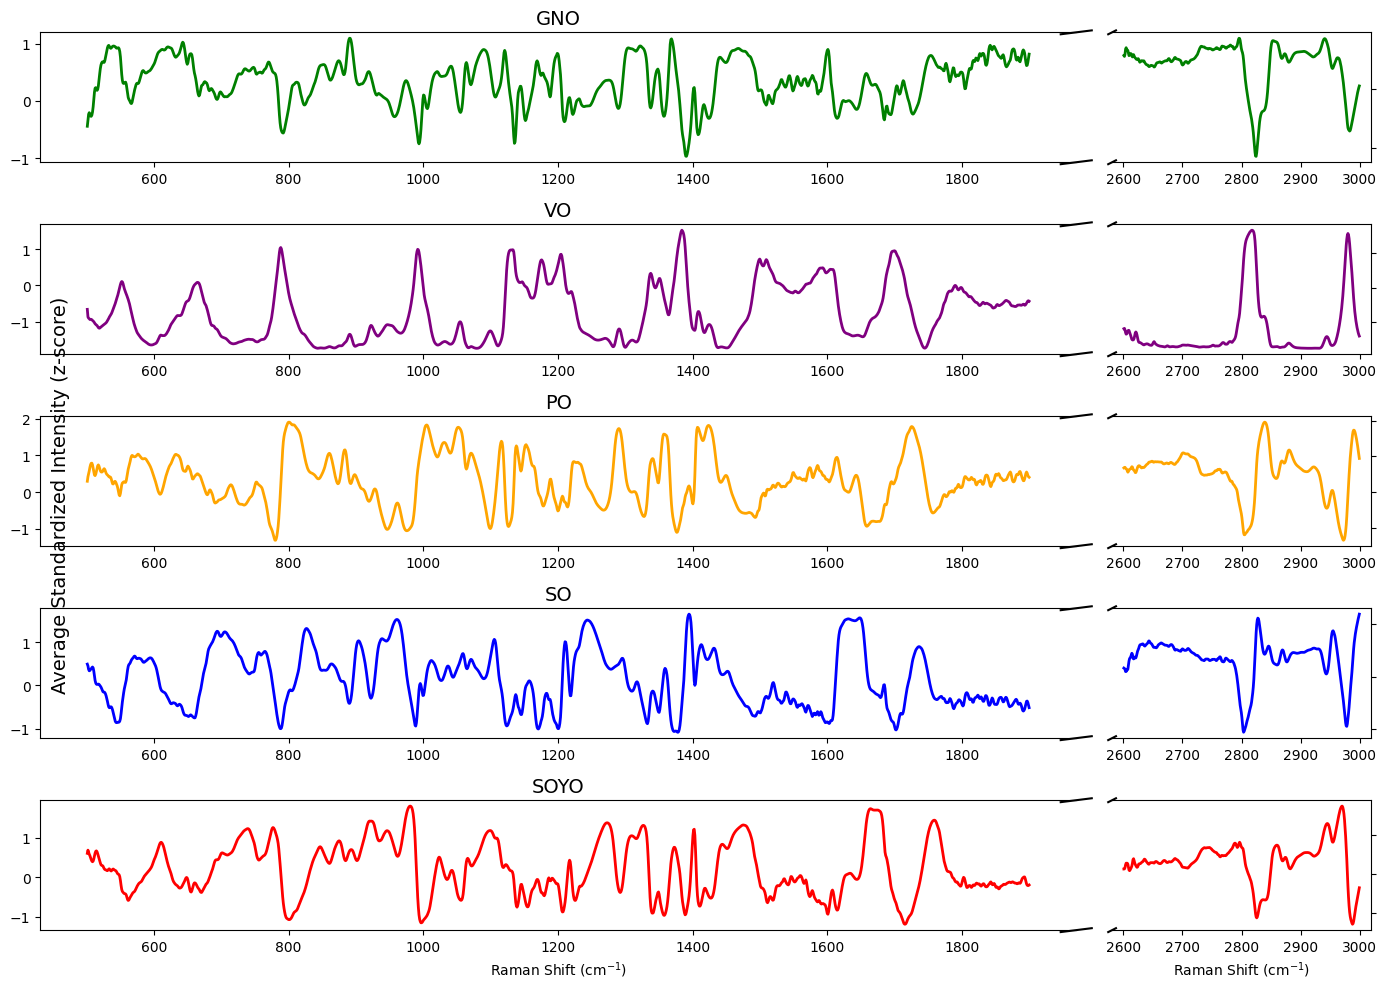

In [45]:
# -------------------------
# Spectral data only
# -------------------------
spectral_data = km_cluster_profile.copy()

# Remove count column if present
if "count_in_each_segment" in spectral_data.columns:
    spectral_data = spectral_data.drop(columns=["count_in_each_segment"])

# Raman shifts
x = spectral_data.columns.astype(float)

# Region break
mask1 = x <= 1900
mask2 = x >= 2600

# Use the SAME colors as your t-SNE plots
cluster_colors = {
    "GNO": "green",
    "VO": "purple",
    "PO": "orange",
    "SO": "blue",
    "SOYO": "red"
}

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(
    len(spectral_data.index),
    2,
    figsize=(14, 10),
    gridspec_kw={"width_ratios":[4,1]},
    sharey=False
)

for row, cluster in enumerate(spectral_data.index):

    y = spectral_data.loc[cluster]

    # Left region
    axes[row,0].plot(
        x[mask1],
        y[mask1],
        color=cluster_colors[cluster],
        linewidth=2
    )

    # Right region
    axes[row,1].plot(
        x[mask2],
        y[mask2],
        color=cluster_colors[cluster],
        linewidth=2
    )

    axes[row,0].set_title(cluster, fontsize=14)

    # Hide touching spines
    axes[row,0].spines["right"].set_visible(False)
    axes[row,1].spines["left"].set_visible(False)

    axes[row,1].yaxis.tick_right()
    axes[row,1].tick_params(labelright=False)

    # Break marks
    d = .015

    kwargs = dict(
        transform=axes[row,0].transAxes,
        color='k',
        clip_on=False
    )

    axes[row,0].plot((1-d,1+d),(-d,+d), **kwargs)
    axes[row,0].plot((1-d,1+d),(1-d,1+d), **kwargs)

    kwargs.update(transform=axes[row,1].transAxes)

    axes[row,1].plot((-d,+d),(-d,+d), **kwargs)
    axes[row,1].plot((-d,+d),(1-d,1+d), **kwargs)

# Labels
axes[-1,0].set_xlabel("Raman Shift (cm$^{-1}$)")
axes[-1,1].set_xlabel("Raman Shift (cm$^{-1}$)")

fig.text(
    0.04,
    0.5,
    "Average Standardized Intensity (z-score)",
    va='center',
    rotation='vertical',
    fontsize=14
)

plt.tight_layout()

plt.savefig(r"Images\K-Means Clusters\cluster_profiles_broken_axis.jpg", dpi=300,bbox_inches="tight")
plt.show()

In [46]:
print(km_cluster_profile.index)
print(mapping)

Index(['GNO', 'VO', 'PO', 'SO', 'SOYO'], dtype='object', name='K_means_segments')
{0: 'GNO', 1: 'VO', 2: 'PO', 3: 'SO', 4: 'SOYO'}


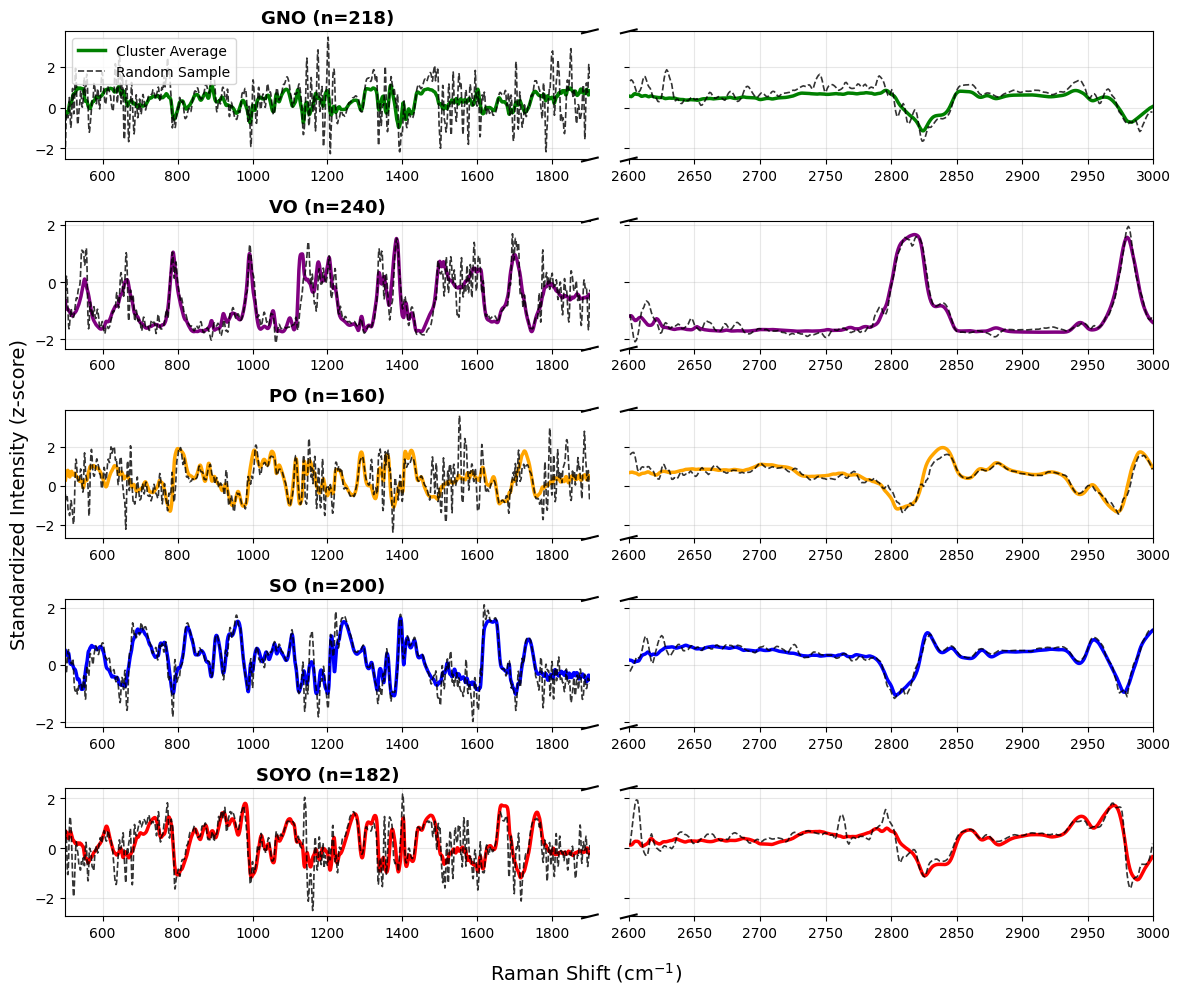

In [47]:
# ==========================================
# Spectral columns only
# ==========================================
spectral_df = df1.iloc[:, :-1]

# Raman shifts
x = spectral_df.columns.astype(float)

# Regions to keep
mask_left = x <= 1900
mask_right = x >= 2600

# Oil -> Cluster mapping
oil_to_cluster = {v: k for k, v in mapping.items()}

# ==========================================
# Figure
# ==========================================
fig = plt.figure(figsize=(12, 10))

for row, oil in enumerate(km_cluster_profile.index):

    # Create broken axis pair
    ax1 = plt.subplot(5, 2, 2*row + 1)
    ax2 = plt.subplot(5, 2, 2*row + 2, sharey=ax1)

    # Average spectrum
    avg_spectrum = km_cluster_profile.loc[oil].drop("count_in_each_segment")
    avg_spectrum.index = avg_spectrum.index.astype(float)

    # Cluster number
    cluster_num = oil_to_cluster[oil]

    # Random spectrum
    random_row = (
        df1[df1["K_means_segments"] == cluster_num]
        .sample(1, random_state=42)
        .iloc[0, :-1]
    )

    random_row.index = random_row.index.astype(float)

    # ==========================
    # LEFT REGION
    # ==========================
    ax1.plot(
        avg_spectrum.index[mask_left],
        avg_spectrum.values[mask_left],
        color=palette[oil],
        lw=2.5,
        label="Cluster Average"
    )

    ax1.plot(
        random_row.index[mask_left],
        random_row.values[mask_left],
        'k--',
        lw=1.2,
        alpha=0.8,
        label="Random Sample"
    )

    # ==========================
    # RIGHT REGION
    # ==========================
    ax2.plot(
        avg_spectrum.index[mask_right],
        avg_spectrum.values[mask_right],
        color=palette[oil],
        lw=2.5
    )

    ax2.plot(
        random_row.index[mask_right],
        random_row.values[mask_right],
        'k--',
        lw=1.2,
        alpha=0.8
    )

    # ==========================
    # Formatting
    # ==========================
    count = km_cluster_profile.loc[oil, "count_in_each_segment"]

    ax1.set_title(
        f"{oil} (n={count})",
        fontsize=13,
        fontweight="bold"
    )

    ax1.set_xlim(500, 1900)
    ax2.set_xlim(2600, 3000)

    ax1.grid(alpha=0.3)
    ax2.grid(alpha=0.3)

    # Hide touching spines
    ax1.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    ax2.tick_params(labelleft=False)

    # Broken-axis marks
    d = .015

    kwargs = dict(transform=ax1.transAxes,
                  color='k',
                  clip_on=False)

    ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
    ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

    kwargs.update(transform=ax2.transAxes)

    ax2.plot((-d, +d), (-d, +d), **kwargs)
    ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

    if row == 0:
        ax1.legend(loc="upper left")

# ==========================================
# Common labels
# ==========================================
fig.supxlabel(
    "Raman Shift (cm$^{-1}$)",
    fontsize=14
)

fig.supylabel(
    "Standardized Intensity (z-score)",
    fontsize=14
)

plt.tight_layout()

# ==========================================
# Save
# ==========================================
plt.savefig(r"Images\K-Means Clusters\cluster_average_vs_random_broken_axis.jpg", dpi=600,bbox_inches="tight")
plt.show()